# 03 — Visualización y Análisis Exploratorio INE

**TFG: Spain's Migratory Flow**  
**Input:** `output/clean/ine_provincia_anio.csv`  
**Output:** Figuras en `output/03_visualizacion/ine/`

### Preguntas que responde este notebook
1. ¿Qué provincias tienen mayor / menor renta media? ¿Ha cambiado entre 2015-2023?
2. ¿Cómo se distribuye la desigualdad (Gini) en el territorio?
3. ¿Qué relación hay entre renta, Gini y estructura demográfica?
4. ¿Qué provincias son más dependientes de pensiones vs salario?
5. ¿Hay clusters de provincias con perfil socioeconómico similar?

Todas las figuras se guardan en alta resolución para incluir en la memoria del TFG.

In [11]:
#=====================================================================
# CELDA 1: Config, rutas y carga de los ficheros limpios
# Fuente: output/clean/ generado en 02_limpieza_ine.ipynb
#=====================================================================

# ── Librerías ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── Estilo visual ─────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# ── Rutas ─────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'output').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

CLEAN_DIR  = PROJECT_ROOT / 'output' / 'clean'
OUTPUT_DIR = PROJECT_ROOT / 'output' / 'visualizaciones'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT :', PROJECT_ROOT)
print('CLEAN_DIR    :', CLEAN_DIR)
print('OUTPUT_DIR   :', OUTPUT_DIR)
print('CLEAN existe :', CLEAN_DIR.exists())

# ── Ficheros limpios disponibles ──────────────────────────────────
FILES = {
    'renta_mun'           : CLEAN_DIR / 'renta_municipio.csv',
    'renta_sec'           : CLEAN_DIR / 'renta_seccion.csv',
    'fuente_ing_mun'      : CLEAN_DIR / 'fuente_ingresos_municipio.csv',
    'fuente_ing_sec'      : CLEAN_DIR / 'fuente_ingresos_seccion.csv',
    'umbrales_edad_mun'   : CLEAN_DIR / 'umbrales_edad_municipio.csv',
    'umbrales_edad_sec'   : CLEAN_DIR / 'umbrales_edad_seccion.csv',
    'umbrales_nac_mun'    : CLEAN_DIR / 'umbrales_nacionalidad_municipio.csv',
    'umbrales_nac_sec'    : CLEAN_DIR / 'umbrales_nacionalidad_seccion.csv',
    'gini_mun'            : CLEAN_DIR / 'gini_municipio.csv',
    'gini_sec'            : CLEAN_DIR / 'gini_seccion.csv',
    'demografico_mun'     : CLEAN_DIR / 'demografico_municipio.csv',
    'demografico_sec'     : CLEAN_DIR / 'demografico_seccion.csv',
}

# ── Constantes de carga ───────────────────────────────────────────
ENCODING  = 'utf-8-sig'
SEPARATOR = ';'

# ── Verificación ficheros ─────────────────────────────────────────
print('\n🔍 Verificando ficheros limpios:')
all_ok = True
for nombre, path in FILES.items():
    estado = '✅' if path.exists() else '❌ NO ENCONTRADO'
    if not path.exists(): all_ok = False
    size_mb = f'{path.stat().st_size/(1024**2):.1f} MB' if path.exists() else '---'
    print(f'  {estado}  {nombre:<22} → {size_mb:>9}  {path.name}')

print(f'\n{"✅ Todos los ficheros encontrados" if all_ok else "❌ Revisa los ficheros marcados"}')

PROJECT_ROOT : c:\Users\Daniel Bolaños\OneDrive\Documentos\GitHub\TFG_Spain-s_Migratory_Flow
CLEAN_DIR    : c:\Users\Daniel Bolaños\OneDrive\Documentos\GitHub\TFG_Spain-s_Migratory_Flow\output\clean
OUTPUT_DIR   : c:\Users\Daniel Bolaños\OneDrive\Documentos\GitHub\TFG_Spain-s_Migratory_Flow\output\visualizaciones
CLEAN existe : True

🔍 Verificando ficheros limpios:
  ✅  renta_mun              →   34.1 MB  renta_municipio.csv
  ✅  renta_sec              →  174.7 MB  renta_seccion.csv
  ✅  fuente_ing_mun         →   28.5 MB  fuente_ingresos_municipio.csv
  ✅  fuente_ing_sec         →  145.5 MB  fuente_ingresos_seccion.csv
  ✅  umbrales_edad_mun      →  265.6 MB  umbrales_edad_municipio.csv
  ✅  umbrales_edad_sec      → 1283.5 MB  umbrales_edad_seccion.csv
  ✅  umbrales_nac_mun       →  168.0 MB  umbrales_nacionalidad_municipio.csv
  ✅  umbrales_nac_sec       →  817.6 MB  umbrales_nacionalidad_seccion.csv
  ✅  gini_mun               →   10.0 MB  gini_municipio.csv
  ✅  gini_sec           

In [12]:
#=====================================================================
# CELDA 2: Carga y construcción del dataset wide a nivel municipio
# Un municipio-año por fila, un indicador por columna
# Base para matrices de correlación y todos los análisis siguientes
#=====================================================================

# ── Carga solo nivel municipio (los más ligeros) ─────────────────
print("📂 Cargando ficheros nivel municipio...")

df_renta    = pd.read_csv(FILES['renta_mun'],      sep=SEPARATOR, encoding=ENCODING)
df_fuente   = pd.read_csv(FILES['fuente_ing_mun'], sep=SEPARATOR, encoding=ENCODING)
df_gini     = pd.read_csv(FILES['gini_mun'],       sep=SEPARATOR, encoding=ENCODING)
df_demo     = pd.read_csv(FILES['demografico_mun'],sep=SEPARATOR, encoding=ENCODING)

print(f"  ✅ renta       : {len(df_renta):>8,} filas")
print(f"  ✅ fuente_ing  : {len(df_fuente):>8,} filas")
print(f"  ✅ gini        : {len(df_gini):>8,} filas")
print(f"  ✅ demografico : {len(df_demo):>8,} filas")

# ── Filtramos secreto estadístico y nos quedamos con valor real ───
def a_wide(df, col_indicador, prefijo=''):
    """
    Convierte formato largo → ancho filtrando secreto estadístico.
    Keys: cod_municipio + periodo
    """
    df_clean = df[~df['secreto_estadistico']].copy()
    pivot = (
        df_clean
        .groupby(['cod_municipio', 'periodo', col_indicador])['valor']
        .mean()  # por si hay duplicados
        .unstack(col_indicador)
        .reset_index()
    )
    if prefijo:
        pivot.columns = (
            ['cod_municipio', 'periodo'] +
            [f"{prefijo}_{c}" for c in pivot.columns[2:]]
        )
    # Limpieza de nombres de columna
    pivot.columns = [
        c.lower()
         .replace(' ', '_')
         .replace('/', '_')
         .replace(':', '')
         .replace('.', '')
         .replace('á','a').replace('é','e').replace('í','i')
         .replace('ó','o').replace('ú','u').replace('ñ','n')
        for c in pivot.columns
    ]
    return pivot

print("\n🔄 Pivotando a formato wide...")

wide_renta  = a_wide(df_renta,  'indicador')
wide_fuente = a_wide(df_fuente, 'indicador')
wide_gini   = a_wide(df_gini,   'indicador')
wide_demo   = a_wide(df_demo,   'indicador')

print(f"  renta   wide : {wide_renta.shape}")
print(f"  fuente  wide : {wide_fuente.shape}")
print(f"  gini    wide : {wide_gini.shape}")
print(f"  demo    wide : {wide_demo.shape}")

# ── Join de todos en un único DataFrame ───────────────────────────
print("\n🔗 Uniendo en dataset maestro...")

df_wide = (
    wide_renta
    .merge(wide_fuente,  on=['cod_municipio', 'periodo'], how='outer')
    .merge(wide_gini,    on=['cod_municipio', 'periodo'], how='outer')
    .merge(wide_demo,    on=['cod_municipio', 'periodo'], how='outer')
)

print(f"  Shape final  : {df_wide.shape[0]:,} filas × {df_wide.shape[1]} columnas")
print(f"\n  Columnas disponibles:")
for col in df_wide.columns:
    n_ok  = df_wide[col].notna().sum()
    pct   = n_ok / len(df_wide) * 100
    print(f"    {col:<60} {n_ok:>8,}  ({pct:>5.1f}% no nulo)")

print("\n✅ Dataset wide listo para correlaciones")

📂 Cargando ficheros nivel municipio...
  ✅ renta       :  439,506 filas
  ✅ fuente_ing  :  366,255 filas
  ✅ gini        :  146,502 filas
  ✅ demografico :  512,757 filas

🔄 Pivotando a formato wide...
  renta   wide : (66637, 8)
  fuente  wide : (60469, 7)
  gini    wide : (61300, 4)
  demo    wide : (66570, 9)

🔗 Uniendo en dataset maestro...
  Shape final  : 66,799 filas × 22 columnas

  Columnas disponibles:
    cod_municipio                                                  66,799  (100.0% no nulo)
    periodo                                                        66,799  (100.0% no nulo)
    media_de_la_renta_por_unidad_de_consumo                        59,249  ( 88.7% no nulo)
    mediana_de_la_renta_por_unidad_de_consumo                      59,249  ( 88.7% no nulo)
    renta_bruta_media_por_hogar                                    64,569  ( 96.7% no nulo)
    renta_bruta_media_por_persona                                  64,569  ( 96.7% no nulo)
    renta_neta_media_por_hogar  

⏳ Calculando correlación Spearman...
  Matriz: (20, 20)


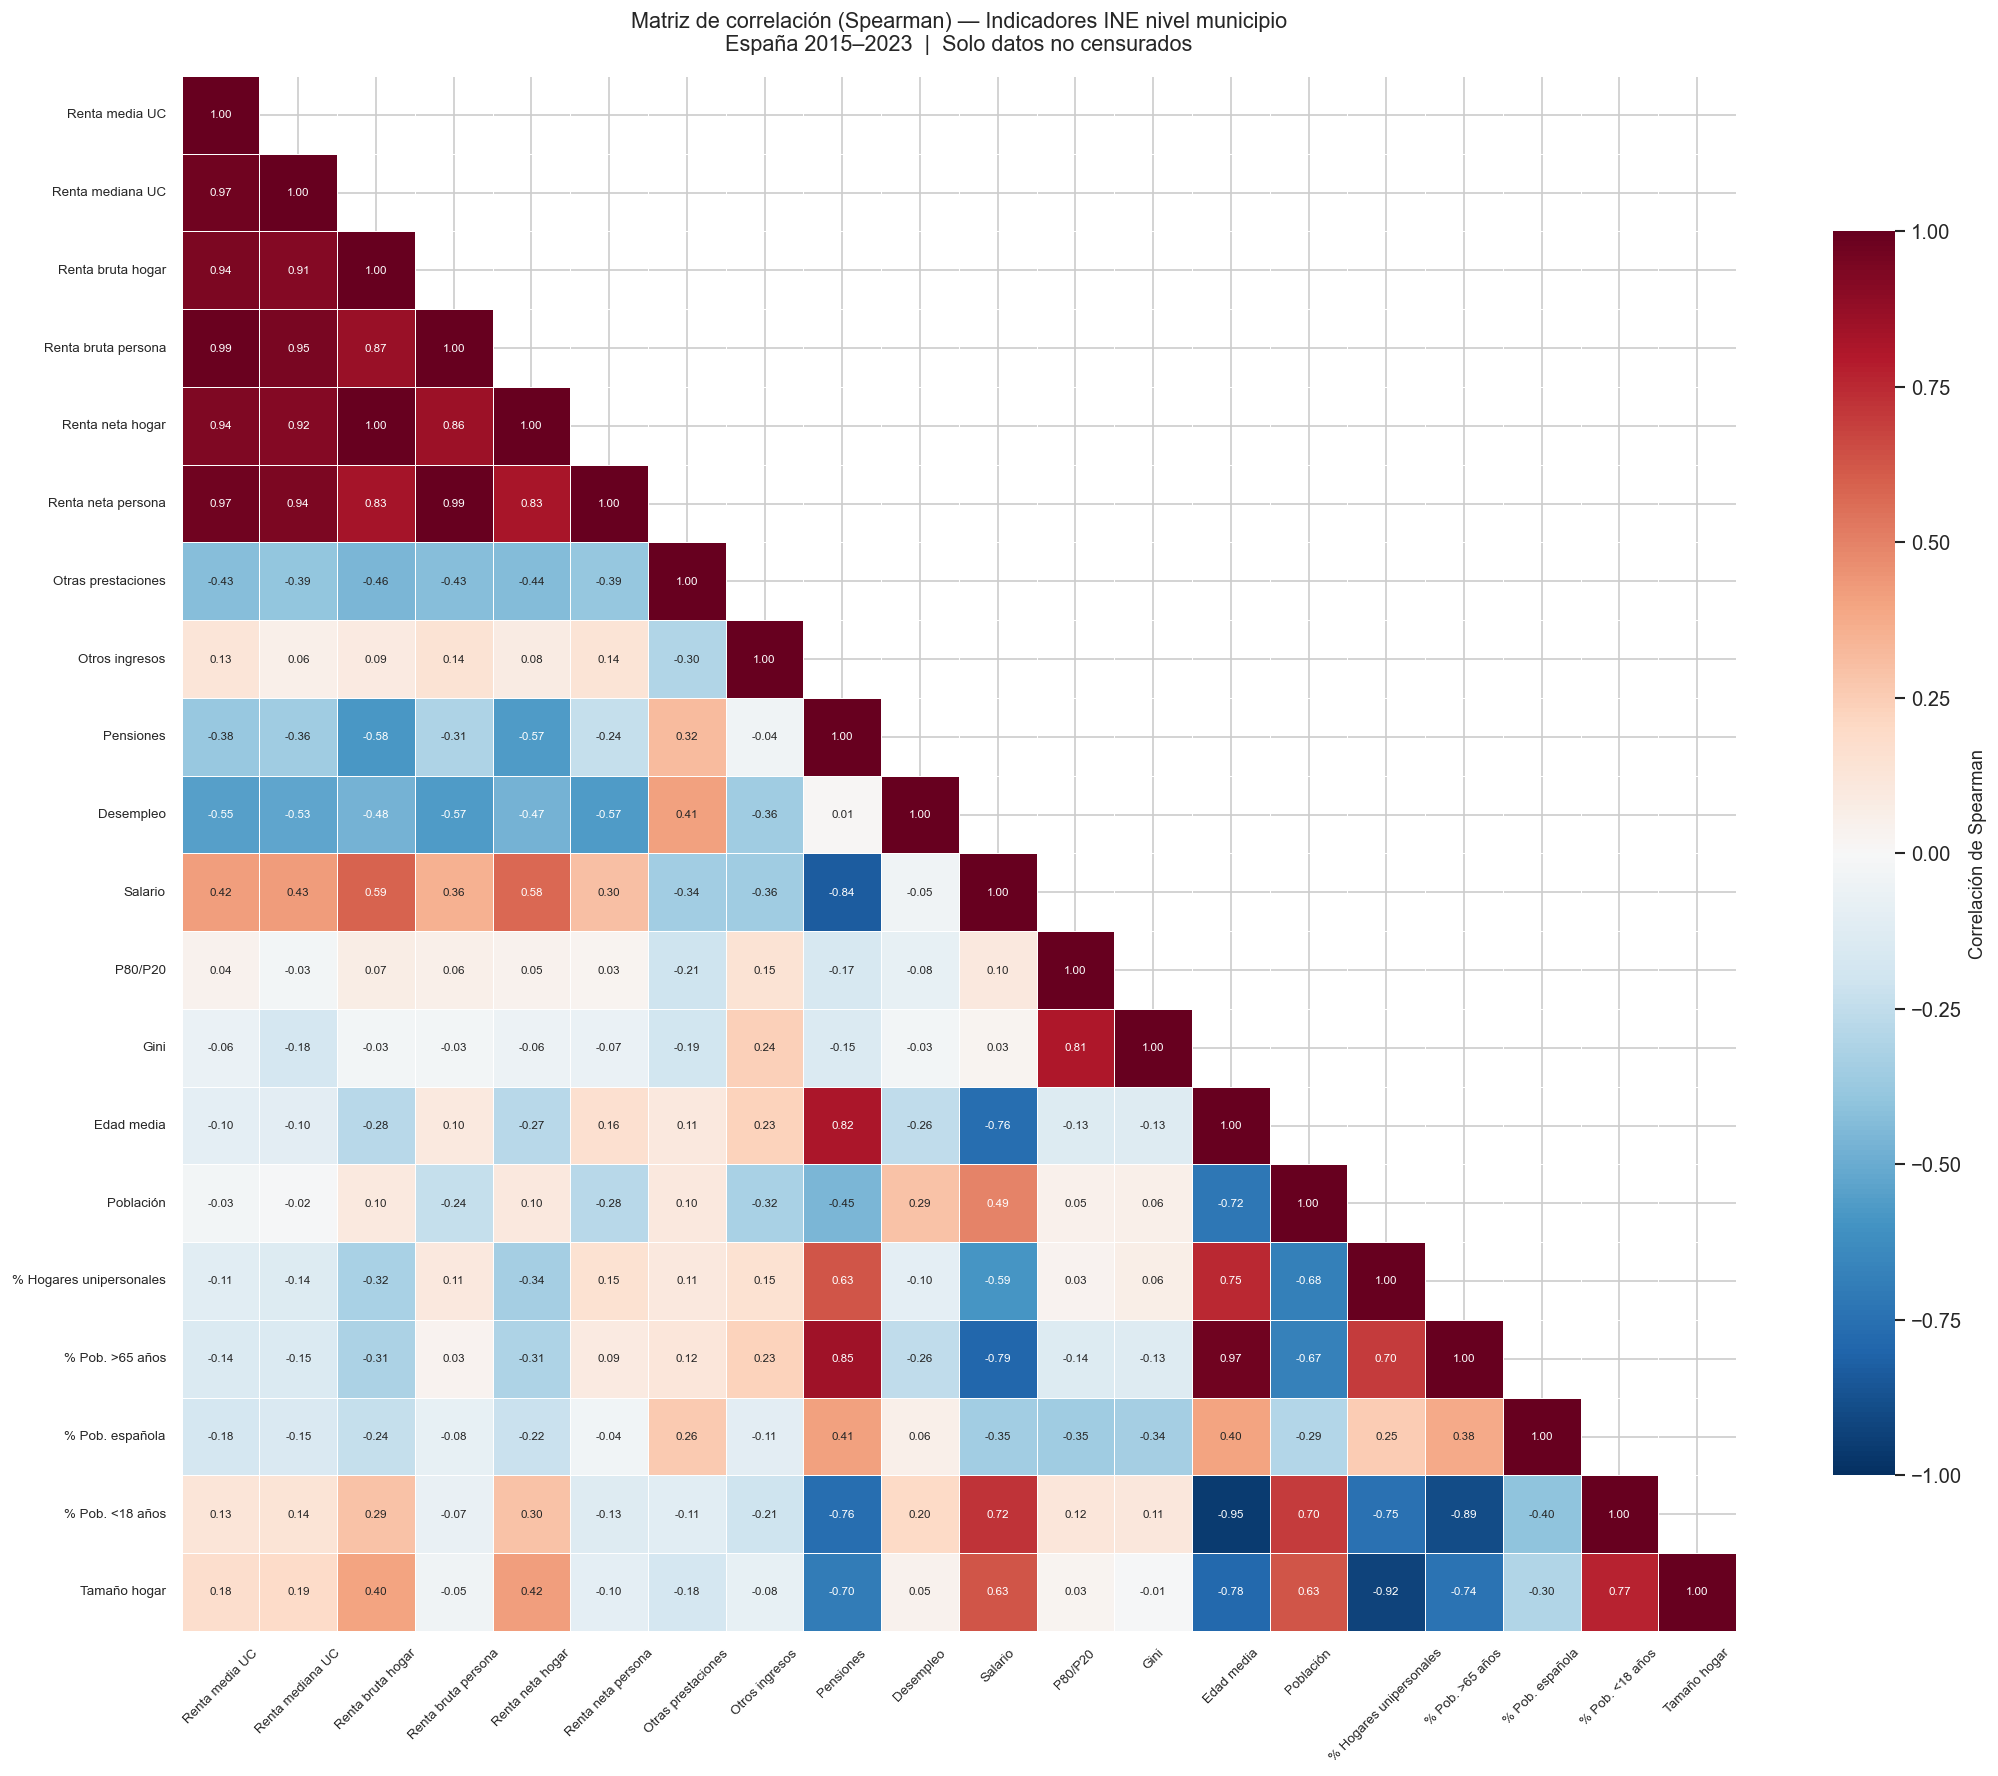


✅ Gráfico guardado en: c:\Users\Daniel Bolaños\OneDrive\Documentos\GitHub\TFG_Spain-s_Migratory_Flow\output\visualizaciones\correlacion_spearman_municipio.png

📊 TOP 20 CORRELACIONES MÁS FUERTES (sin diagonal, sin pares renta×renta)
             Variable A              Variable B  Spearman r
        % Pob. >65 años              Edad media    0.969343
        % Pob. <18 años              Edad media   -0.953820
           Tamaño hogar % Hogares unipersonales   -0.922903
        % Pob. <18 años         % Pob. >65 años   -0.891022
        % Pob. >65 años               Pensiones    0.850716
                Salario               Pensiones   -0.835055
             Edad media               Pensiones    0.816925
                   Gini                 P80/P20    0.806564
        % Pob. >65 años                 Salario   -0.793163
           Tamaño hogar              Edad media   -0.782888
           Tamaño hogar         % Pob. <18 años    0.772435
        % Pob. <18 años               Pensione

In [13]:
#=====================================================================
# CELDA 3: Matriz de correlación — todas las variables numéricas
# Método Spearman (más robusto con distribuciones no normales)
# Guardamos el gráfico en output/visualizaciones/
#=====================================================================

# ── Columnas numéricas para correlación ──────────────────────────
COLS_CORR = [
    'media_de_la_renta_por_unidad_de_consumo',
    'mediana_de_la_renta_por_unidad_de_consumo',
    'renta_bruta_media_por_hogar',
    'renta_bruta_media_por_persona',
    'renta_neta_media_por_hogar',
    'renta_neta_media_por_persona',
    'fuente_de_ingreso_otras_prestaciones',
    'fuente_de_ingreso_otros_ingresos',
    'fuente_de_ingreso_pensiones',
    'fuente_de_ingreso_prestaciones_por_desempleo',
    'fuente_de_ingreso_salario',
    'distribucion_de_la_renta_p80_p20',
    'indice_de_gini',
    'edad_media_de_la_poblacion',
    'poblacion',
    'porcentaje_de_hogares_unipersonales',
    'porcentaje_de_poblacion_de_65_y_mas_anos',
    'porcentaje_de_poblacion_espanola',
    'porcentaje_de_poblacion_menor_de_18_anos',
    'tamano_medio_del_hogar',
]

ETIQUETAS = {
    'media_de_la_renta_por_unidad_de_consumo'        : 'Renta media UC',
    'mediana_de_la_renta_por_unidad_de_consumo'      : 'Renta mediana UC',
    'renta_bruta_media_por_hogar'                    : 'Renta bruta hogar',
    'renta_bruta_media_por_persona'                  : 'Renta bruta persona',
    'renta_neta_media_por_hogar'                     : 'Renta neta hogar',
    'renta_neta_media_por_persona'                   : 'Renta neta persona',
    'fuente_de_ingreso_otras_prestaciones'           : 'Otras prestaciones',
    'fuente_de_ingreso_otros_ingresos'               : 'Otros ingresos',
    'fuente_de_ingreso_pensiones'                    : 'Pensiones',
    'fuente_de_ingreso_prestaciones_por_desempleo'   : 'Desempleo',
    'fuente_de_ingreso_salario'                      : 'Salario',
    'distribucion_de_la_renta_p80_p20'               : 'P80/P20',
    'indice_de_gini'                                 : 'Gini',
    'edad_media_de_la_poblacion'                     : 'Edad media',
    'poblacion'                                      : 'Población',
    'porcentaje_de_hogares_unipersonales'            : '% Hogares unipersonales',
    'porcentaje_de_poblacion_de_65_y_mas_anos'       : '% Pob. >65 años',
    'porcentaje_de_poblacion_espanola'               : '% Pob. española',
    'porcentaje_de_poblacion_menor_de_18_anos'       : '% Pob. <18 años',
    'tamano_medio_del_hogar'                         : 'Tamaño hogar',
}

# ── Calcular correlación Spearman ─────────────────────────────────
print("⏳ Calculando correlación Spearman...")
corr = (
    df_wide[COLS_CORR]
    .rename(columns=ETIQUETAS)
    .corr(method='spearman')
)
print(f"  Matriz: {corr.shape}")

# ── Gráfico ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 15))

mask_triu = np.triu(np.ones_like(corr, dtype=bool), k=1)  # oculta triángulo superior (sin diagonal)

sns.heatmap(
    corr,
    mask=mask_triu,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 7},
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Correlación de Spearman'}
)

ax.set_title(
    'Matriz de correlación (Spearman) — Indicadores INE nivel municipio\n'
    'España 2015–2023  |  Solo datos no censurados',
    fontsize=13, pad=15
)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
ruta = OUTPUT_DIR / 'correlacion_spearman_municipio.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico guardado en: {ruta}")

# ── Top correlaciones: triángulo inferior SIN diagonal ────────────
print("\n📊 TOP 20 CORRELACIONES MÁS FUERTES (sin diagonal, sin pares renta×renta)")

mask_lower = np.tril(np.ones_like(corr, dtype=bool), k=-1)  # solo triángulo inferior sin diagonal

corr_pairs = (
    corr
    .where(mask_lower)
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Variable A', 'Variable B', 'Spearman r']
corr_pairs['|r|'] = corr_pairs['Spearman r'].abs()

vars_renta = ['Renta media UC', 'Renta mediana UC', 'Renta bruta hogar',
              'Renta bruta persona', 'Renta neta hogar', 'Renta neta persona']
mask_redund = (
    corr_pairs['Variable A'].isin(vars_renta) &
    corr_pairs['Variable B'].isin(vars_renta)
)

top = (
    corr_pairs[~mask_redund]
    .sort_values('|r|', ascending=False)
    .head(20)
)
print(top[['Variable A', 'Variable B', 'Spearman r']].to_string(index=False))

print("\n🎯 CORRELACIONES CON '% Pob. española' (variable clave del TFG)")
clave = (
    corr_pairs[
        (corr_pairs['Variable A'] == '% Pob. española') |
        (corr_pairs['Variable B'] == '% Pob. española')
    ]
    .sort_values('|r|', ascending=False)
)
print(clave[['Variable A', 'Variable B', 'Spearman r']].to_string(index=False))

In [18]:
#=====================================================================
# CELDA 4 (DEFINITIVA): Descarga y carga GeoJSON provincias
# Fuente: github.com/codeforgermany — cod_prov coincide con INE
#=====================================================================

import urllib.request
import geopandas as gpd

URL_GEO = 'https://github.com/codeforgermany/click_that_hood/raw/main/public/data/spain-provinces.geojson'
GEO_DIR = PROJECT_ROOT / 'data' / 'geo'
GEO_DIR.mkdir(parents=True, exist_ok=True)
ruta_geo = GEO_DIR / 'spain_provincias.geojson'

# ── Descarga (solo si no existe) ──────────────────────────────────
if not ruta_geo.exists():
    print("⬇️  Descargando GeoJSON provincias...")
    urllib.request.urlretrieve(URL_GEO, ruta_geo)
    print(f"  ✅ Guardado en: {ruta_geo}")
else:
    print(f"✅ GeoJSON ya existe — omitiendo descarga")

# ── Cargar con geopandas ──────────────────────────────────────────
gdf_prov = gpd.read_file(ruta_geo)

# Normalizar cod_prov → string 2 dígitos con cero
gdf_prov['cod_prov'] = gdf_prov['cod_prov'].astype(str).str.zfill(2)

print(f"\n✅ GeoDataFrame cargado: {gdf_prov.shape[0]} provincias")
print(f"   CRS: {gdf_prov.crs}")
print(f"   Columnas: {gdf_prov.columns.tolist()}")
print(f"\n   Primeras 5 filas:")
print(gdf_prov[['cod_prov', 'name', 'cod_ccaa']].head(5).to_string(index=False))

# ── Verificar cobertura del join con nuestros datos ───────────────
cod_nuestros = set(
    df_wide['cod_municipio'].astype(str).str.zfill(5).str[:2].unique()
)
cod_geo = set(gdf_prov['cod_prov'].unique())

print(f"\n🔍 Verificación join:")
print(f"   Códigos en nuestros datos : {len(cod_nuestros)}")
print(f"   Códigos en GeoJSON        : {len(cod_geo)}")
print(f"   Match                     : {len(cod_nuestros & cod_geo)}")
sin_geo = cod_nuestros - cod_geo
if sin_geo:
    print(f"   ⚠️  Sin geometría         : {sorted(sin_geo)}")
else:
    print(f"   ✅ Cobertura completa — todos los códigos tienen geometría")

⬇️  Descargando GeoJSON provincias...
  ✅ Guardado en: c:\Users\Daniel Bolaños\OneDrive\Documentos\GitHub\TFG_Spain-s_Migratory_Flow\data\geo\spain_provincias.geojson

✅ GeoDataFrame cargado: 52 provincias
   CRS: EPSG:4326
   Columnas: ['cod_prov', 'name', 'cod_ccaa', 'cartodb_id', 'created_at', 'updated_at', 'geometry']

   Primeras 5 filas:
cod_prov          name cod_ccaa
      07 Illes Balears       03
      33      Asturias       18
      15      A Coruña       11
      17        Girona       08
      35    Las Palmas       04

🔍 Verificación join:
   Códigos en nuestros datos : 52
   Códigos en GeoJSON        : 52
   Match                     : 52
   ✅ Cobertura completa — todos los códigos tienen geometría


In [15]:
#=====================================================================
# CELDA 5 — BLOQUE 1: Mapas geográficos
# G1 · Mapa renta neta media por persona por provincia (último año)
# G6 · Mapa Gini por provincia (último año)
#=====================================================================

import geopandas as gpd

# ── Cargar shapefile provincias ───────────────────────────────────
shp_prov = list((GEO_DIR / 'provincias').glob('*.shp'))[0]
gdf_prov = gpd.read_file(shp_prov)

print("Columnas shapefile provincias:", gdf_prov.columns.tolist())
print("CRS:", gdf_prov.crs)
print(gdf_prov[['NATCODE', 'NAMEUNIT']].head(10))

IndexError: list index out of range

In [ ]:
#=====================================================================
# CELDA 6 — BLOQUE 2: Inmigración y territorio
# G3 · Scatter % Pob. extranjera vs Renta neta por municipio
# G4 · Scatter % Pob. extranjera vs Gini por municipio
# G5 · Evolución temporal % pob. extranjera por provincia — barras
#=====================================================================

# ── Preparar datos: último año disponible ────────────────────────
ultimo_anio = df_wide['periodo'].max()
df_ultimo   = df_wide[df_wide['periodo'] == ultimo_anio].copy()

# % población extranjera = 100 - % española
df_ultimo['pct_extranjera'] = 100 - df_ultimo['porcentaje_de_poblacion_espanola']

# Añadir nombre provincia
df_ultimo['cod_provincia'] = df_ultimo['cod_municipio'].astype(str).str.zfill(5).str[:2]

print(f"Año de análisis: {ultimo_anio}")
print(f"Municipios con datos completos: {df_ultimo.dropna(subset=['renta_neta_media_por_persona','pct_extranjera','indice_de_gini']).shape[0]:,}")

# ── G3 · Scatter % extranjera vs Renta neta ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

df_g3 = df_ultimo.dropna(subset=['renta_neta_media_por_persona', 'pct_extranjera']).copy()

scatter = axes[0].scatter(
    df_g3['pct_extranjera'],
    df_g3['renta_neta_media_por_persona'],
    c=df_g3['cod_provincia'].astype('category').cat.codes,
    cmap='tab20',
    alpha=0.35,
    s=15,
    linewidths=0
)

# Línea de tendencia
z = np.polyfit(df_g3['pct_extranjera'], df_g3['renta_neta_media_por_persona'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_g3['pct_extranjera'].min(), df_g3['pct_extranjera'].max(), 200)
axes[0].plot(x_line, p(x_line), color='crimson', linewidth=2, label=f'Tendencia lineal')

from scipy import stats
r, pval = stats.spearmanr(df_g3['pct_extranjera'], df_g3['renta_neta_media_por_persona'])
axes[0].set_title(f'% Pob. extranjera vs Renta neta por persona\n{ultimo_anio}  |  Spearman r={r:.2f}  p={pval:.2e}', fontsize=12)
axes[0].set_xlabel('% Población extranjera')
axes[0].set_ylabel('Renta neta media por persona (€)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend(fontsize=9)

# ── G4 · Scatter % extranjera vs Gini ────────────────────────────
df_g4 = df_ultimo.dropna(subset=['indice_de_gini', 'pct_extranjera']).copy()

axes[1].scatter(
    df_g4['pct_extranjera'],
    df_g4['indice_de_gini'],
    c=df_g4['cod_provincia'].astype('category').cat.codes,
    cmap='tab20',
    alpha=0.35,
    s=15,
    linewidths=0
)

z2 = np.polyfit(df_g4['pct_extranjera'], df_g4['indice_de_gini'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df_g4['pct_extranjera'].min(), df_g4['pct_extranjera'].max(), 200)
axes[1].plot(x_line2, p2(x_line2), color='crimson', linewidth=2, label='Tendencia lineal')

r2, pval2 = stats.spearmanr(df_g4['pct_extranjera'], df_g4['indice_de_gini'])
axes[1].set_title(f'% Pob. extranjera vs Índice de Gini\n{ultimo_anio}  |  Spearman r={r2:.2f}  p={pval2:.2e}', fontsize=12)
axes[1].set_xlabel('% Población extranjera')
axes[1].set_ylabel('Índice de Gini')
axes[1].legend(fontsize=9)

plt.suptitle(f'Inmigración y estructura económica municipal — España {ultimo_anio}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
ruta = OUTPUT_DIR / 'scatter_inmigracion_renta_gini.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ G3+G4 guardados en: {ruta}")

# ── G5 · Evolución % pob. extranjera por provincia ───────────────
df_g5 = (
    df_wide
    .assign(
        pct_extranjera = lambda d: 100 - d['porcentaje_de_poblacion_espanola'],
        cod_provincia  = lambda d: d['cod_municipio'].astype(str).str.zfill(5).str[:2]
    )
    .dropna(subset=['pct_extranjera'])
    .groupby(['cod_provincia', 'periodo'])['pct_extranjera']
    .mean()
    .reset_index()
)

# Top 15 provincias con más extranjeros en último año
top_prov = (
    df_g5[df_g5['periodo'] == ultimo_anio]
    .nlargest(15, 'pct_extranjera')['cod_provincia']
    .tolist()
)

COD_PROVINCIA = {
    '01':'Álava',        '02':'Albacete',     '03':'Alicante',    '04':'Almería',
    '05':'Ávila',        '06':'Badajoz',      '07':'Baleares',    '08':'Barcelona',
    '09':'Burgos',       '10':'Cáceres',      '11':'Cádiz',       '12':'Castellón',
    '13':'Ciudad Real',  '14':'Córdoba',      '15':'A Coruña',    '16':'Cuenca',
    '17':'Girona',       '18':'Granada',      '19':'Guadalajara', '20':'Gipuzkoa',
    '21':'Huelva',       '22':'Huesca',       '23':'Jaén',        '24':'León',
    '25':'Lleida',       '26':'La Rioja',     '27':'Lugo',        '28':'Madrid',
    '29':'Málaga',       '30':'Murcia',       '31':'Navarra',     '32':'Ourense',
    '33':'Asturias',     '34':'Palencia',     '35':'Las Palmas',  '36':'Pontevedra',
    '37':'Salamanca',    '38':'S.C. Tenerife','39':'Cantabria',   '40':'Segovia',
    '41':'Sevilla',      '42':'Soria',        '43':'Tarragona',   '44':'Teruel',
    '45':'Toledo',       '46':'Valencia',     '47':'Valladolid',  '48':'Bizkaia',
    '49':'Zamora',       '50':'Zaragoza',     '51':'Ceuta',       '52':'Melilla',
}

df_g5_top = df_g5[df_g5['cod_provincia'].isin(top_prov)].copy()
df_g5_top['provincia'] = df_g5_top['cod_provincia'].map(COD_PROVINCIA)

fig, ax = plt.subplots(figsize=(16, 7))
for prov, grupo in df_g5_top.groupby('provincia'):
    grupo = grupo.sort_values('periodo')
    ax.plot(grupo['periodo'], grupo['pct_extranjera'],
            marker='o', markersize=4, linewidth=1.8, label=prov)

ax.set_title('Evolución % población extranjera — Top 15 provincias\nEspaña 2015–2023',
             fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('% Población extranjera (media municipal)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, ncol=1)
ax.grid(True, alpha=0.4)
plt.tight_layout()
ruta = OUTPUT_DIR / 'evolucion_pct_extranjera_provincias.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ G5 guardado en: {ruta}")

In [ ]:
#=====================================================================
# CELDA 7 — BLOQUE 3: Desigualdad
# G2 · Evolución renta neta por persona — top/bottom 10 provincias
# G7 · Boxplot renta neta por persona por tamaño de municipio
#=====================================================================

# ── Preparar datos provincia-año ─────────────────────────────────
df_prov = (
    df_wide
    .assign(cod_provincia=lambda d: d['cod_municipio'].astype(str).str.zfill(5).str[:2])
    .dropna(subset=['renta_neta_media_por_persona'])
    .groupby(['cod_provincia', 'periodo'])['renta_neta_media_por_persona']
    .mean()
    .reset_index()
)
df_prov['provincia'] = df_prov['cod_provincia'].map(COD_PROVINCIA)

# Top y bottom 10 en último año
ultimo = df_prov['periodo'].max()
ranking = df_prov[df_prov['periodo'] == ultimo].nlargest(10, 'renta_neta_media_por_persona')
bottom  = df_prov[df_prov['periodo'] == ultimo].nsmallest(10, 'renta_neta_media_por_persona')
prov_sel = pd.concat([ranking, bottom])['cod_provincia'].tolist()

# ── G2 · Evolución temporal renta — top/bottom 10 ────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for prov, grupo in df_prov[df_prov['cod_provincia'].isin(ranking['cod_provincia'])].groupby('provincia'):
    grupo = grupo.sort_values('periodo')
    axes[0].plot(grupo['periodo'], grupo['renta_neta_media_por_persona'],
                 marker='o', markersize=4, linewidth=1.8, label=prov)

axes[0].set_title(f'Top 10 provincias más ricas\n(renta neta media por persona)', fontsize=11)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Renta neta media por persona (€)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

for prov, grupo in df_prov[df_prov['cod_provincia'].isin(bottom['cod_provincia'])].groupby('provincia'):
    grupo = grupo.sort_values('periodo')
    axes[1].plot(grupo['periodo'], grupo['renta_neta_media_por_persona'],
                 marker='o', markersize=4, linewidth=1.8, label=prov, linestyle='--')

axes[1].set_title(f'Bottom 10 provincias más pobres\n(renta neta media por persona)', fontsize=11)
axes[1].set_xlabel('Año')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

plt.suptitle('Evolución renta neta por persona — Top/Bottom 10 provincias\nEspaña 2015–2023',
             fontsize=14, fontweight='bold')
plt.tight_layout()
ruta = OUTPUT_DIR / 'evolucion_renta_top_bottom_provincias.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ G2 guardado en: {ruta}")

# ── G7 · Boxplot renta por tamaño de municipio ───────────────────
df_box = (
    df_wide[df_wide['periodo'] == ultimo]
    .dropna(subset=['renta_neta_media_por_persona', 'poblacion'])
    .copy()
)

bins   = [0, 1_000, 10_000, 100_000, float('inf')]
labels = ['< 1.000 hab', '1.000–10.000 hab', '10.000–100.000 hab', '> 100.000 hab']
df_box['tamaño'] = pd.cut(df_box['poblacion'], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df_box,
    x='tamaño',
    y='renta_neta_media_por_persona',
    order=labels,
    palette='muted',
    width=0.5,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)
ax.set_title(f'Renta neta por persona según tamaño de municipio — España {ultimo}', fontsize=13)
ax.set_xlabel('Tamaño del municipio')
ax.set_ylabel('Renta neta media por persona (€)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
ruta = OUTPUT_DIR / 'boxplot_renta_tamano_municipio.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ G7 guardado en: {ruta}")

In [ ]:
#=====================================================================
# CELDA 8 — BLOQUE 4: Fuentes de ingreso
# G8 · Heatmap provincias × fuente de ingreso (último año)
# G9 · Evolución salario vs pensiones vs desempleo — área apilada
#=====================================================================

FUENTES = [
    'fuente_de_ingreso_salario',
    'fuente_de_ingreso_pensiones',
    'fuente_de_ingreso_prestaciones_por_desempleo',
    'fuente_de_ingreso_otras_prestaciones',
    'fuente_de_ingreso_otros_ingresos',
]
FUENTES_ETIQ = {
    'fuente_de_ingreso_salario'                    : 'Salario',
    'fuente_de_ingreso_pensiones'                  : 'Pensiones',
    'fuente_de_ingreso_prestaciones_por_desempleo' : 'Desempleo',
    'fuente_de_ingreso_otras_prestaciones'         : 'Otras prestaciones',
    'fuente_de_ingreso_otros_ingresos'             : 'Otros ingresos',
}

# ── G8 · Heatmap provincias × fuente de ingreso ──────────────────
df_g8 = (
    df_wide[df_wide['periodo'] == ultimo]
    .assign(cod_provincia=lambda d: d['cod_municipio'].astype(str).str.zfill(5).str[:2])
    .dropna(subset=FUENTES)
    .groupby('cod_provincia')[FUENTES]
    .mean()
    .rename(columns=FUENTES_ETIQ)
    .reset_index()
)
df_g8['provincia'] = df_g8['cod_provincia'].map(COD_PROVINCIA)
df_g8 = df_g8.set_index('provincia').drop(columns='cod_provincia')
df_g8 = df_g8.sort_values('Salario', ascending=False)

fig, ax = plt.subplots(figsize=(12, 16))
sns.heatmap(
    df_g8,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    annot_kws={'size': 8},
    ax=ax,
    cbar_kws={'label': '% hogares con esa fuente como principal'}
)
ax.set_title(f'Composición fuentes de ingreso por provincia — España {ultimo}\n(% medio municipal, ordenado por % salario)',
             fontsize=12, pad=15)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
ruta = OUTPUT_DIR / 'heatmap_fuentes_ingreso_provincias.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ G8 guardado en: {ruta}")

# ── G9 · Evolución nacional salario vs pensiones vs desempleo ────
df_g9 = (
    df_wide
    .dropna(subset=FUENTES)
    .groupby('periodo')[FUENTES]
    .mean()
    .rename(columns=FUENTES_ETIQ)
    .reset_index()
    .sort_values('periodo')
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(
    df_g9['periodo'],
    [df_g9[c] for c in FUENTES_ETIQ.values()],
    labels=list(FUENTES_ETIQ.values()),
    alpha=0.85
)
ax.set_title('Evolución composición fuentes de ingreso — España 2015–2023\n(media municipal nacional)',
             fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('% medio de hogares por fuente')
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
ruta = OUTPUT_DIR / 'evolucion_fuentes_ingreso_nacional.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ G9 guardado en: {ruta}")